In [2]:
import sys
import numpy as np
from pathlib import Path
from pyPolCal.csv_tools import write_fits_info_to_csv,read_csv,read_csv_physical_model_all_bins
from pyPolCal.fitting import *
from pyPolCal.utils import *
from pyPolCal.plotting import plot_data_and_model
from pyMuellerMat.physical_models.charis_physical_models import *
from matplotlib.ticker import MultipleLocator
import matplotlib.pyplot as plt
import pandas as pd
# Plot settings that I like
plt.rcParams.update({
    #"text.usetex": True,
    #"font.family": "serif",
   # "font.serif": ["Palatino"],
    "font.size": 16,
   # "text.latex.preamble": r"\usepackage{amsmath}\usepackage{mathpazo}"
})
from pyPolCal.constants import wavelength_bins


# Step 1: Write FITS Info to CSV

This CSV writer will organize all relevant header information. Some header information is excluded from the extracted cubes but exists in the raw files. This function will match the info from raw headers by matching tags in the filenames. The CHARIS DPP rewrites these tags, so if you used the DPP at any point you will need to retitle all the frames to their original titles (there is a function in csv_tools.py to do this).

In [3]:
# Get paths to both processed and raw data 
# Make sure these directories have cubes with corresonding numbers
cube_dir = '/home/thomasmc/nbs_in/unpol/cubes'
raw_dir = '/home/thomasmc/nbs_in/unpol/raw'
csv_dir = '/home/thomasmc/nbs_in/unpol/csvs'

# Write all bins to csvs
for bin in range(0,22):
   csv_filepath = f'/home/thomasmc/nbs_in/unpol/csvs/bin{bin}.csv'
   write_fits_info_to_csv(cube_dir, raw_dir, csv_filepath,bin)



CSV file written to /home/thomasmc/nbs_in/unpol/csvs/bin0.csv
CSV file written to /home/thomasmc/nbs_in/unpol/csvs/bin1.csv
CSV file written to /home/thomasmc/nbs_in/unpol/csvs/bin2.csv
CSV file written to /home/thomasmc/nbs_in/unpol/csvs/bin3.csv
CSV file written to /home/thomasmc/nbs_in/unpol/csvs/bin4.csv
CSV file written to /home/thomasmc/nbs_in/unpol/csvs/bin5.csv
CSV file written to /home/thomasmc/nbs_in/unpol/csvs/bin6.csv
CSV file written to /home/thomasmc/nbs_in/unpol/csvs/bin7.csv
CSV file written to /home/thomasmc/nbs_in/unpol/csvs/bin8.csv
CSV file written to /home/thomasmc/nbs_in/unpol/csvs/bin9.csv
CSV file written to /home/thomasmc/nbs_in/unpol/csvs/bin10.csv
CSV file written to /home/thomasmc/nbs_in/unpol/csvs/bin11.csv
CSV file written to /home/thomasmc/nbs_in/unpol/csvs/bin12.csv
CSV file written to /home/thomasmc/nbs_in/unpol/csvs/bin13.csv
CSV file written to /home/thomasmc/nbs_in/unpol/csvs/bin14.csv
CSV file written to /home/thomasmc/nbs_in/unpol/csvs/bin15.csv
CS

I'm also going to remove all entries with a 45 deg derotator angle, the SNR is too high due to polarimetric efficiency issues

In [ ]:
# remove first 8 entries from csv
from pathlib import Path

for csv in Path('../datacsvs/nbs_in_internalcal_unpol').glob('*.csv'):
    df = pd.read_csv(csv)
    df = df.iloc[8:]  # Remove first 8 entries
    #df.to_csv(csv, index=False)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.9253e-04                                    9.51e-02    
       1              2         1.2281e-05      5.80e-04       1.21e-02       1.13e-03    
       2              3         1.2197e-05      8.44e-08       1.47e-04       1.69e-07    
       3              4         1.2197e-05      1.87e-15       2.19e-08       5.92e-12    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 5.9253e-04, final cost 1.2197e-05, first-order optimality 5.92e-12.
     message: `gtol` termination condition is satisfied.
     success: True
      status: 1
         fun: [-7.824e-04  2.710e-04 ... -8.559e-05 -6.051e-04]
           x: [ 1.221e-02]
        cost: 1.2197027175722246e-05
         jac: [[ 1.029e-01]
               [ 4.348e-01]
               ...
               [-8.189e-02]
               [-2.498e-01]]
        grad: [ 5.852e-12]
  optimality: 5.92

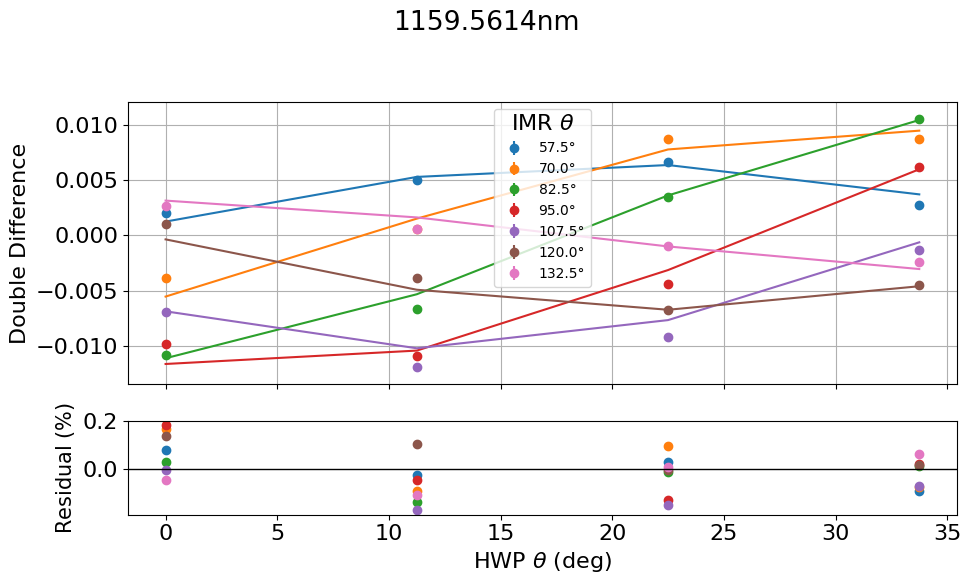

Updated Mueller Matrix:
[[ 0.49804875 -0.15377344  0.03260528  0.47259198]
 [-0.49804875  0.15377344 -0.03260528 -0.47259198]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.17358933808208543 0.18291368942120712
s_res: 0.09505174877391495
Error: [0.00034057]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.8862e-04                                    1.03e-01    
       1              2         5.8573e-06      5.83e-04       1.12e-02       1.14e-03    
       2              3         5.7838e-06      7.34e-08       1.27e-04       1.47e-07    
       3              4         5.7838e-06      1.22e-15       1.64e-08       1.06e-11    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 5.8862e-04, final cost 5.7838e-06, first-order optimality 1.06e-11.
     message: `gtol` termination condition is satisfied.

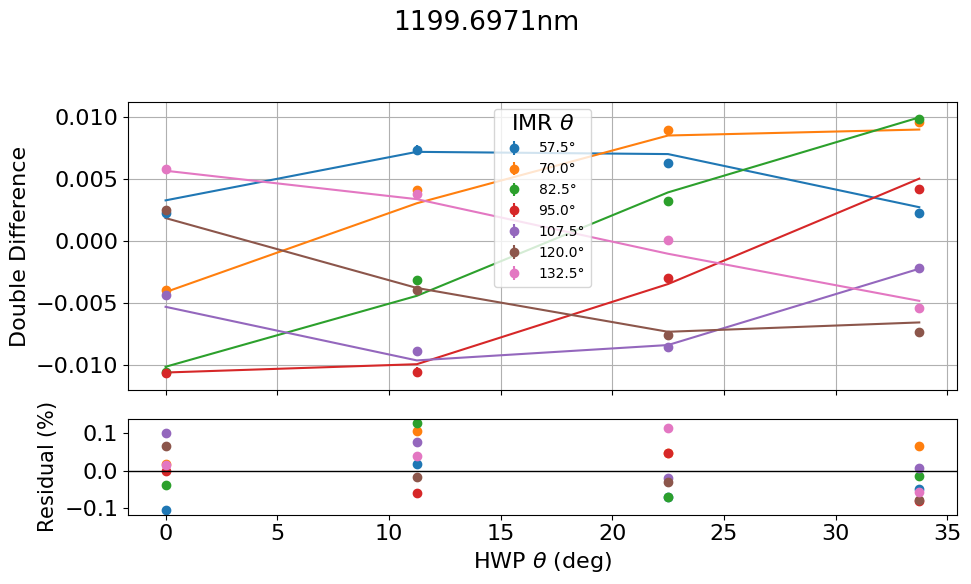

Updated Mueller Matrix:
[[ 0.49720096 -0.24099805  0.11623379  0.41441223]
 [-0.49328234  0.24297978 -0.11714667 -0.41766722]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.10507966049064654 0.12532099949151004
s_res: 0.0654546835141666
Error: [0.00021763]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.0177e-04                                    1.21e-01    
       1              2         2.3761e-06      6.99e-04       1.14e-02       1.37e-03    
       2              3         2.2846e-06      9.15e-08       1.32e-04       1.83e-07    
       3              4         2.2846e-06      1.64e-15       1.77e-08       8.64e-13    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 7.0177e-04, final cost 2.2846e-06, first-order optimality 8.64e-13.
     message: `gtol` termination condition is satisfied.


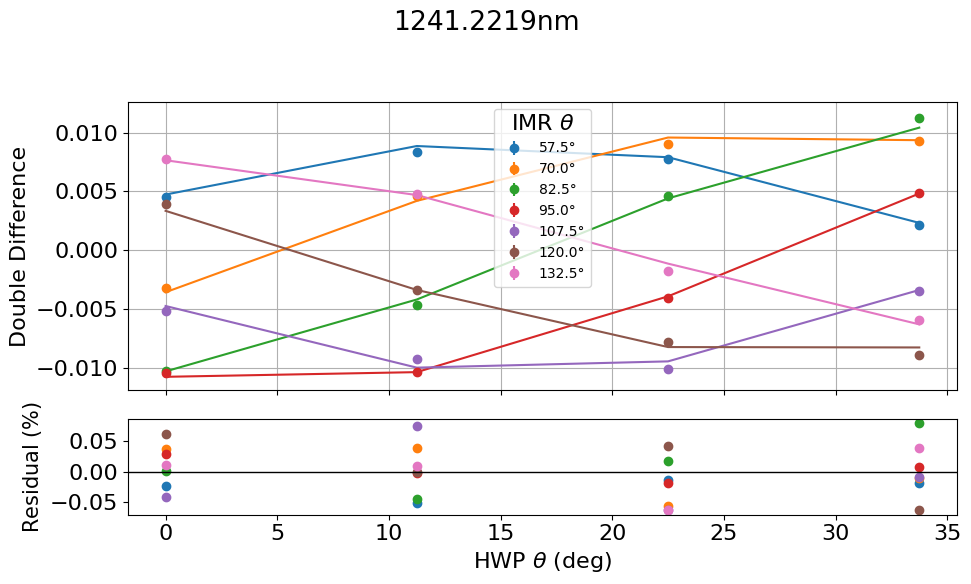

Updated Mueller Matrix:
[[ 0.49648258 -0.29832661  0.17328714  0.35464845]
 [-0.49477528  0.29938088 -0.17387666 -0.35585503]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.06310456131139075 0.07892450896020953
s_res: 0.04113722562592692
Error: [0.00012727]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.3679e-04                                    1.31e-01    
       1              2         2.3220e-06      7.34e-04       1.11e-02       1.44e-03    
       2              3         2.2320e-06      9.00e-08       1.24e-04       1.80e-07    
       3              4         2.2320e-06      1.41e-15       1.55e-08       2.01e-11    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 7.3679e-04, final cost 2.2320e-06, first-order optimality 2.01e-11.
     message: `gtol` termination condition is satisfied.

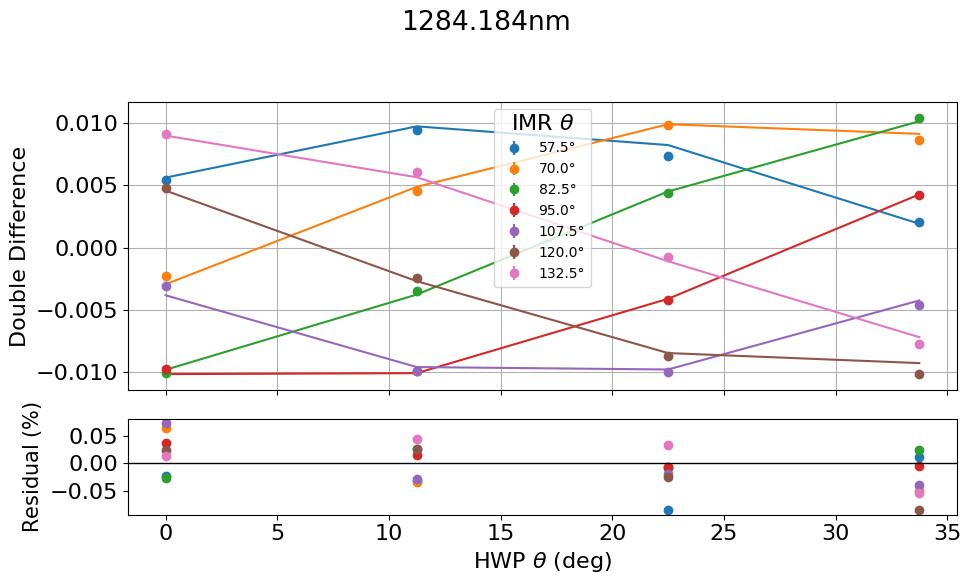

Updated Mueller Matrix:
[[ 0.49610549 -0.34258989  0.22993238  0.2639479 ]
 [-0.48980081  0.34707113 -0.23284531 -0.2672919 ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.0860361758538678 0.07367784837300445
s_res: 0.04066142590214466
Error: [0.00011873]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.7590e-04                                    1.39e-01    
       1              2         1.6740e-06      7.74e-04       1.10e-02       1.51e-03    
       2              3         1.5797e-06      9.43e-08       1.23e-04       1.89e-07    
       3              4         1.5797e-06      1.46e-15       1.53e-08       1.73e-12    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 7.7590e-04, final cost 1.5797e-06, first-order optimality 1.73e-12.
     message: `gtol` termination condition is satisfied.


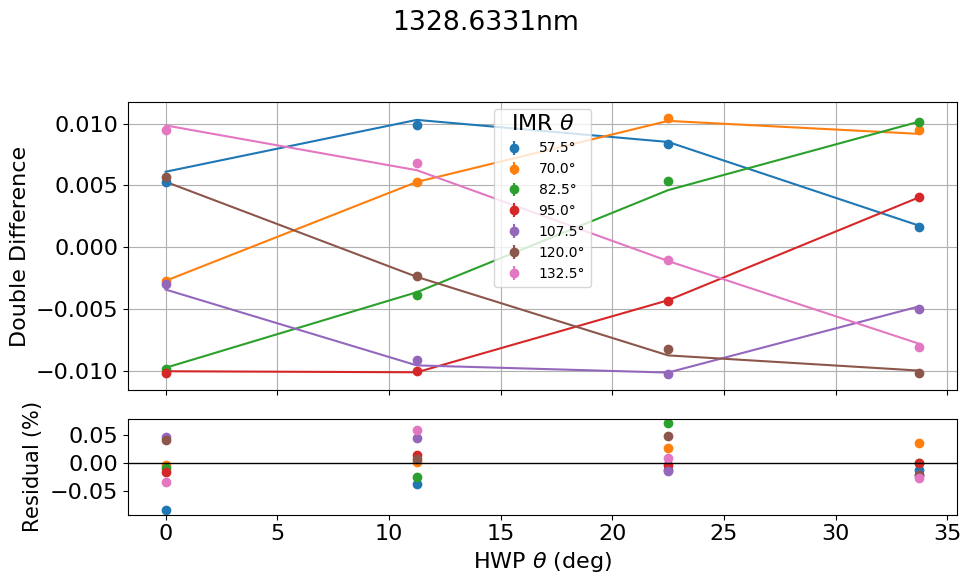

Updated Mueller Matrix:
[[ 0.49588776 -0.36320231  0.26286771  0.18675911]
 [-0.48568897  0.3709288  -0.26829451 -0.19061483]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.08443256469039995 0.07056281203226844
s_res: 0.034207332993237895
Error: [9.6990854e-05]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.3752e-04                                    1.35e-01    
       1              2         9.6218e-07      7.37e-04       1.08e-02       1.44e-03    
       2              3         8.7624e-07      8.59e-08       1.18e-04       1.72e-07    
       3              4         8.7624e-07      1.22e-15       1.41e-08       2.27e-12    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 7.3752e-04, final cost 8.7624e-07, first-order optimality 2.27e-12.
     message: `gtol` termination condition is satisf

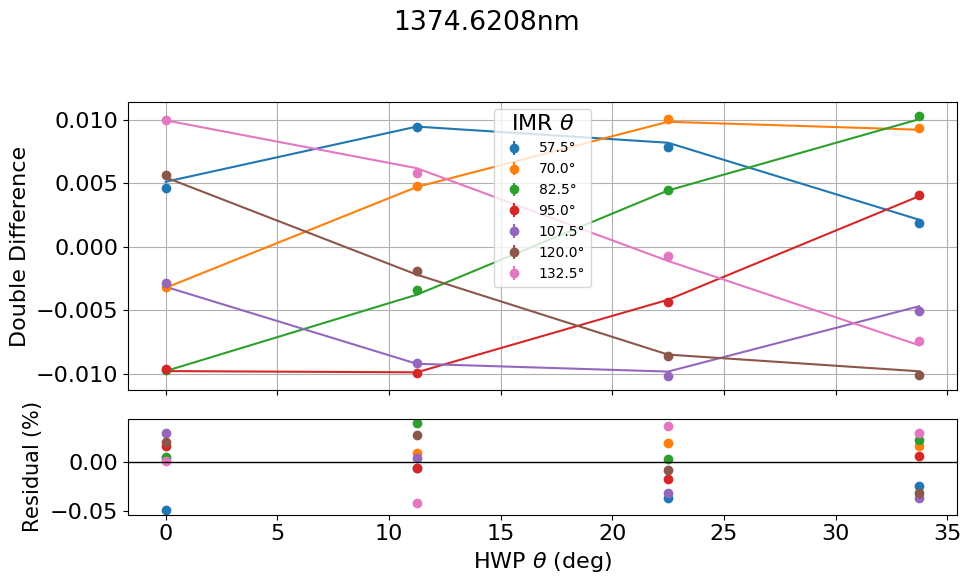

Updated Mueller Matrix:
[[ 0.49632962 -0.33095655  0.30472918 -0.19590988]
 [-0.49068568  0.33482988 -0.30818216  0.19812987]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.049164326066555575 0.04030677914255221
s_res: 0.02547672515497235
Error: [7.24748026e-05]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         6.3532e-04                                    1.19e-01    
       1              2         1.6955e-06      6.34e-04       1.06e-02       1.24e-03    
       2              3         1.6246e-06      7.09e-08       1.13e-04       1.42e-07    
       3              4         1.6246e-06      9.27e-16       1.29e-08       2.85e-12    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 6.3532e-04, final cost 1.6246e-06, first-order optimality 2.85e-12.
     message: `gtol` termination condition is satis

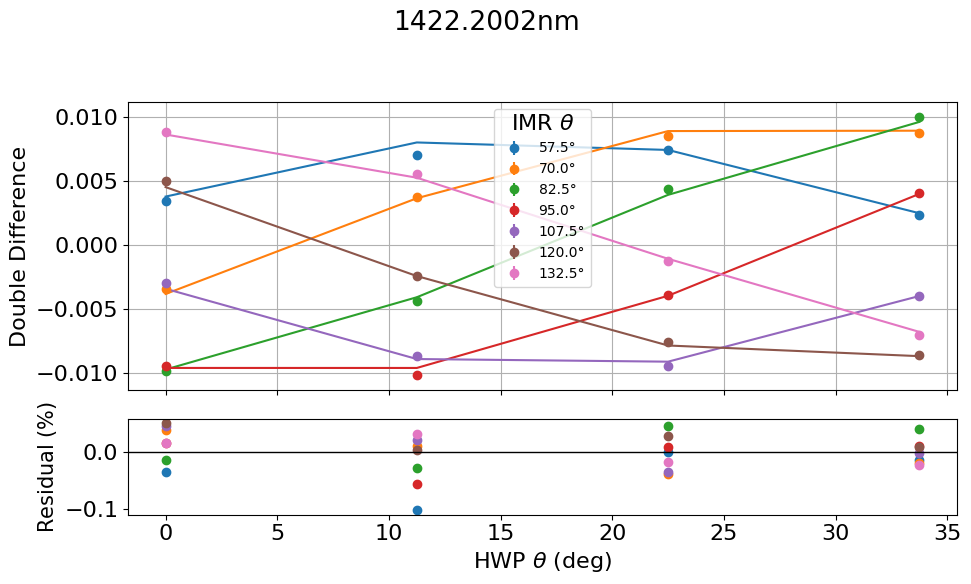

Updated Mueller Matrix:
[[ 0.49692958 -0.28205193  0.27904497 -0.29084027]
 [-0.49194215  0.28498255 -0.28183885  0.29375235]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.10182516369238459 0.050134847550986295
s_res: 0.0346903119627372
Error: [0.00010419]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.0874e-04                                    9.73e-02    
       1              2         6.2977e-07      5.08e-04       1.03e-02       9.95e-04    
       2              3         5.7551e-07      5.43e-08       1.08e-04       1.08e-07    
       3              4         5.7551e-07      6.45e-16       1.18e-08       2.69e-12    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 5.0874e-04, final cost 5.7551e-07, first-order optimality 2.69e-12.
     message: `gtol` termination condition is satisfied.

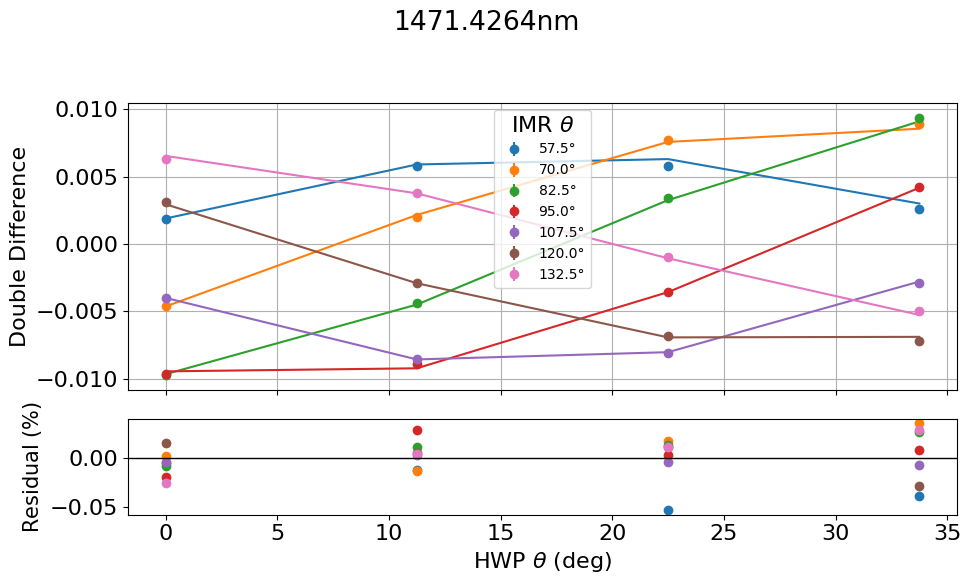

Updated Mueller Matrix:
[[ 0.49780124 -0.20556895  0.22352502 -0.38929617]
 [-0.49373392  0.2073323  -0.22535     0.39247472]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.05375749616061565 0.03473370584813218
s_res: 0.020647126756950657
Error: [6.76216222e-05]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.3126e-04                                    8.28e-02    
       1              2         1.0441e-06      4.30e-04       1.03e-02       8.43e-04    
       2              3         9.9860e-07      4.55e-08       1.07e-04       9.09e-08    
       3              4         9.9860e-07      5.30e-16       1.15e-08       4.89e-12    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 4.3126e-04, final cost 9.9860e-07, first-order optimality 4.89e-12.
     message: `gtol` termination condition is satis

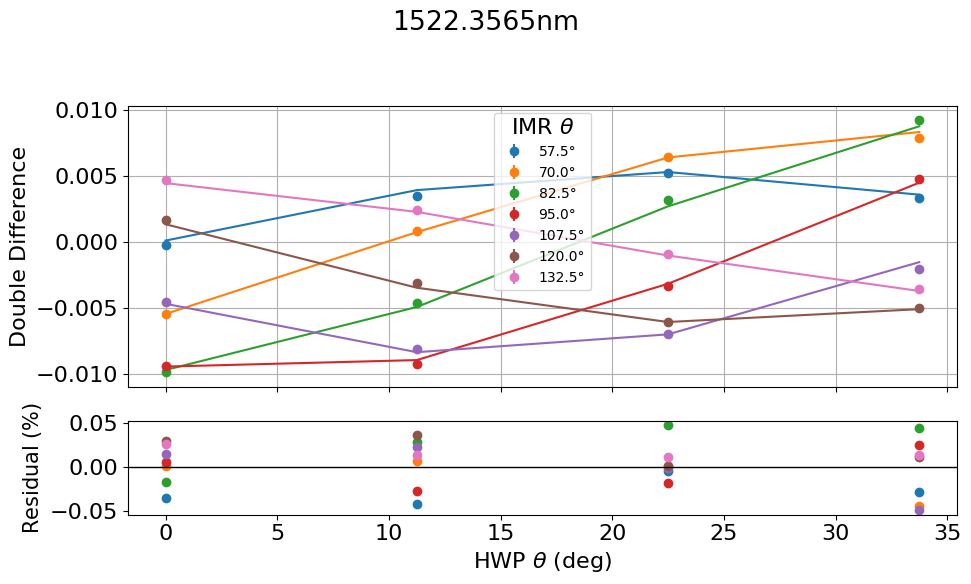

Updated Mueller Matrix:
[[ 0.49862783 -0.12703185  0.15763579 -0.45087579]
 [-0.49424152  0.12824427 -0.15902695  0.45485505]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.04981934201936061 0.04778967360844438
s_res: 0.027197544037116505
Error: [9.63167322e-05]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.8537e-04                                    7.49e-02    
       1              2         6.2035e-07      3.85e-04       1.02e-02       7.54e-04    
       2              3         5.8050e-07      3.98e-08       1.05e-04       7.97e-08    
       3              4         5.8050e-07      4.45e-16       1.11e-08       3.28e-12    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 3.8537e-04, final cost 5.8050e-07, first-order optimality 3.28e-12.
     message: `gtol` termination condition is satis

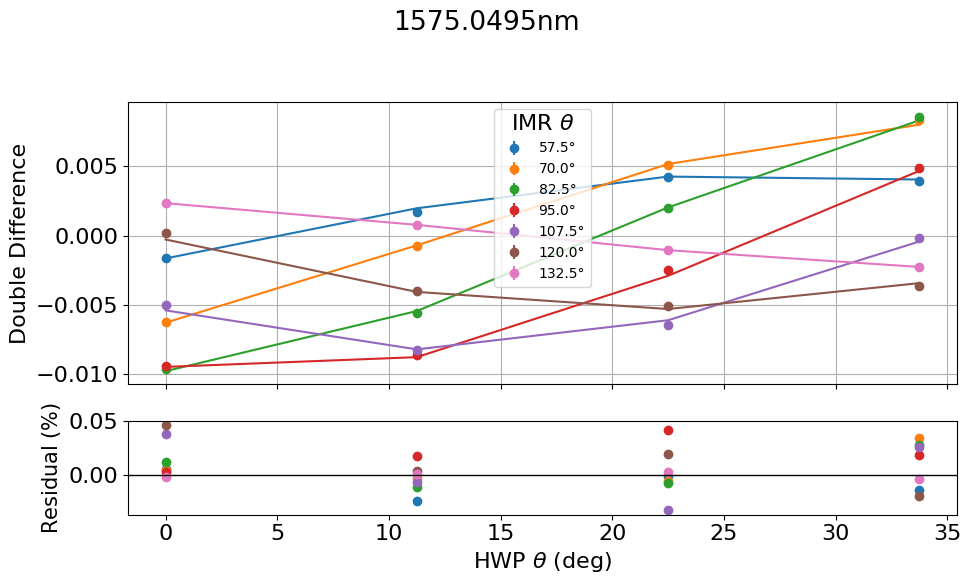

Updated Mueller Matrix:
[[ 0.49940042 -0.05325924  0.08996972 -0.48518887]
 [-0.49632552  0.05365174 -0.09052571  0.48818751]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.03246658648009548 0.04618246489352089
s_res: 0.020736508646686157
Error: [7.68507336e-05]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.5692e-04                                    7.10e-02    
       1              2         5.9230e-07      3.56e-04       9.93e-03       6.99e-04    
       2              3         5.5714e-07      3.52e-08       9.96e-05       7.03e-08    
       3              4         5.5714e-07      3.56e-16       1.00e-08       3.32e-12    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 3.5692e-04, final cost 5.5714e-07, first-order optimality 3.32e-12.
     message: `gtol` termination condition is satis

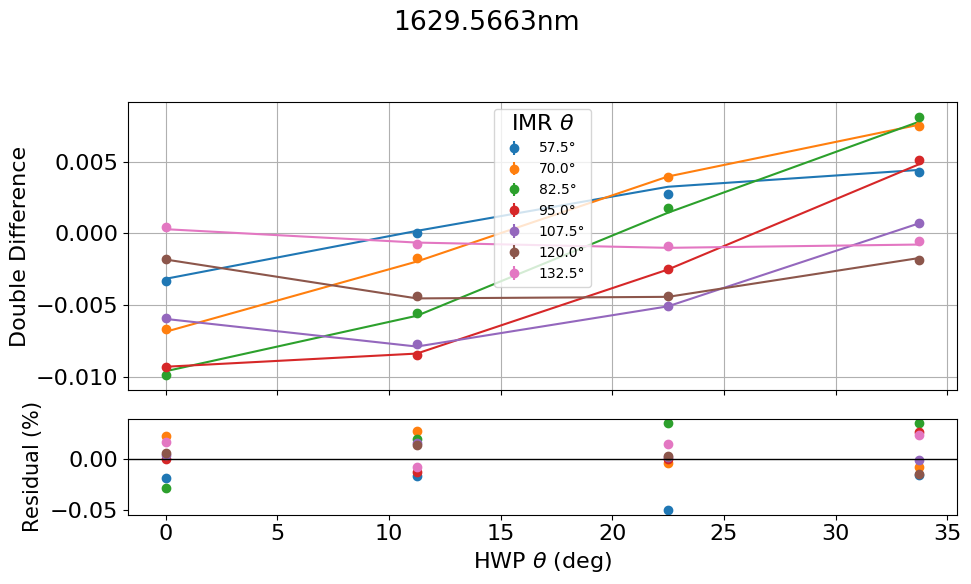

Updated Mueller Matrix:
[[ 0.50012196  0.01715599  0.01895626 -0.49569585]
 [-0.49635438 -0.01721038 -0.01910015  0.49946029]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.04998874589728314 0.03543578390288826
s_res: 0.020315011402241744
Error: [7.6338003e-05]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.5453e-04                                    7.21e-02    
       1              2         6.2071e-07      3.54e-04       9.72e-03       6.94e-04    
       2              3         5.8725e-07      3.35e-08       9.55e-05       6.69e-08    
       3              4         5.8725e-07      3.11e-16       9.20e-09       3.73e-12    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 3.5453e-04, final cost 5.8725e-07, first-order optimality 3.73e-12.
     message: `gtol` termination condition is satisf

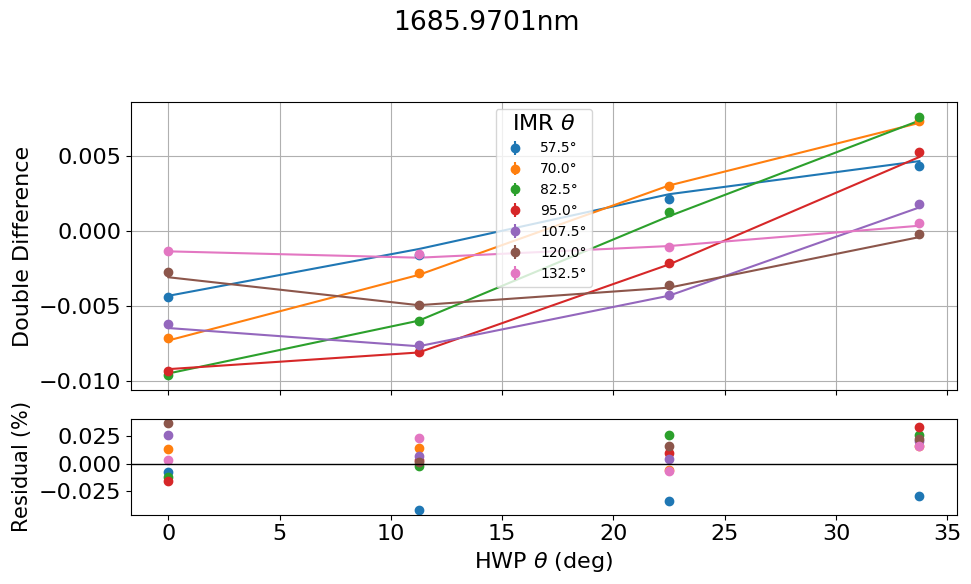

Updated Mueller Matrix:
[[ 0.50066287  0.07245526 -0.04160755 -0.49024706]
 [-0.49731561 -0.07287819  0.04188841  0.49355559]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.04268443978397851 0.03689345544629763
s_res: 0.02085661627737609
Error: [7.69715427e-05]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.5188e-04                                    7.38e-02    
       1              2         4.8455e-07      3.51e-04       9.43e-03       6.90e-04    
       2              3         4.5328e-07      3.13e-08       8.98e-05       6.25e-08    
       3              4         4.5328e-07      2.57e-16       8.14e-09       7.81e-12    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 3.5188e-04, final cost 4.5328e-07, first-order optimality 7.81e-12.
     message: `gtol` termination condition is satisf

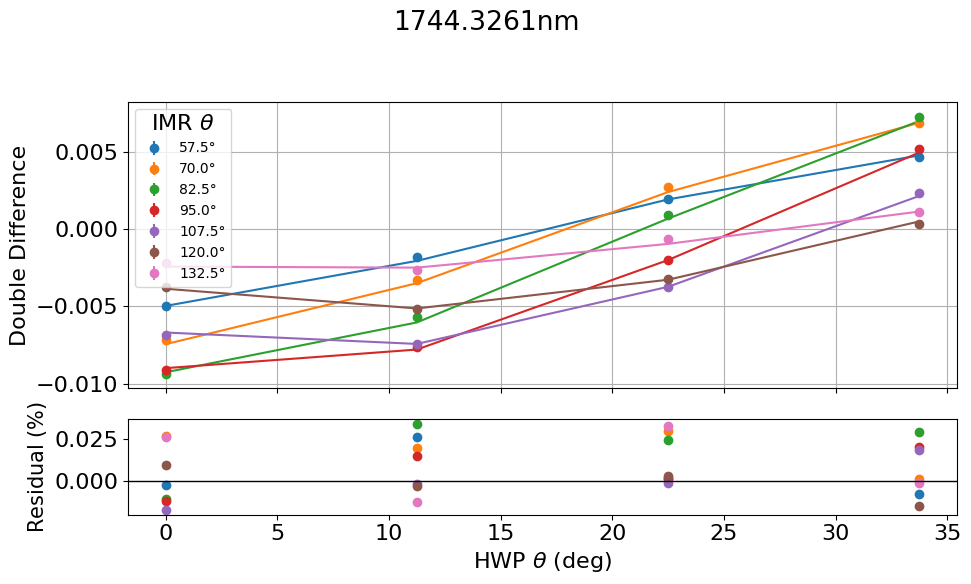

Updated Mueller Matrix:
[[ 0.50099373  0.10919562 -0.08696176 -0.47849274]
 [-0.49843867 -0.10970873  0.08740937  0.4809554 ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.017253030191167085 0.03407010219299045
s_res: 0.018323807042691924
Error: [6.58161745e-05]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.5934e-04                                    7.65e-02    
       1              2         3.8766e-07      3.59e-04       9.30e-03       7.05e-04    
       2              3         3.5664e-07      3.10e-08       8.72e-05       6.20e-08    
       3              4         3.5664e-07      2.40e-16       7.68e-09       9.55e-13    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 3.5934e-04, final cost 3.5664e-07, first-order optimality 9.55e-13.
     message: `gtol` termination condition is sati

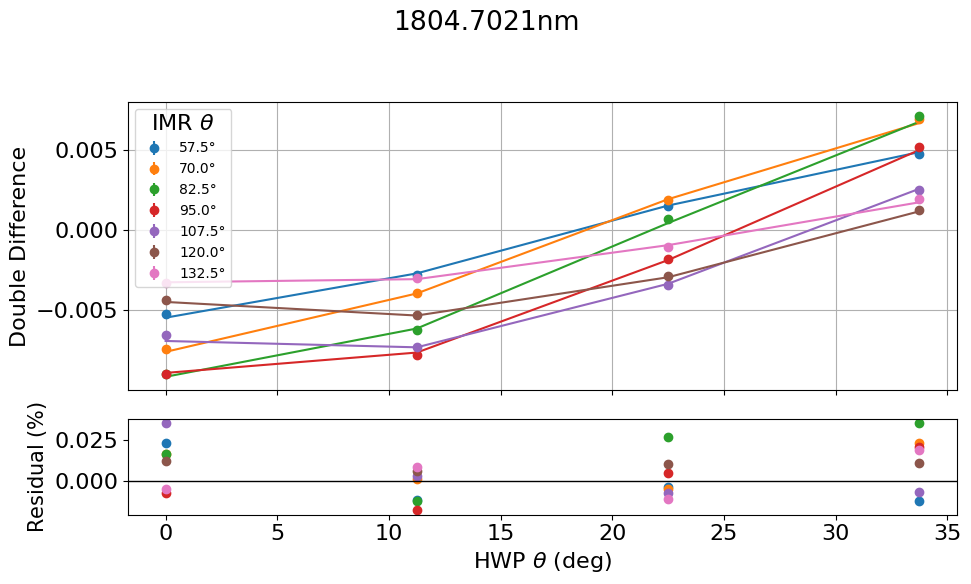

Updated Mueller Matrix:
[[ 0.50122756  0.13563774 -0.12493268 -0.46275645]
 [-0.49814561 -0.13642292  0.12570951  0.46563368]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.017873042577457365 0.035039479992091116
s_res: 0.016253607404446587
Error: [5.69143205e-05]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.5499e-04                                    7.81e-02    
       1              2         5.7290e-07      3.54e-04       9.00e-03       6.96e-04    
       2              3         5.4422e-07      2.87e-08       8.16e-05       5.74e-08    
       3              4         5.4422e-07      1.95e-16       6.73e-09       3.22e-13    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 3.5499e-04, final cost 5.4422e-07, first-order optimality 3.22e-13.
     message: `gtol` termination condition is sat

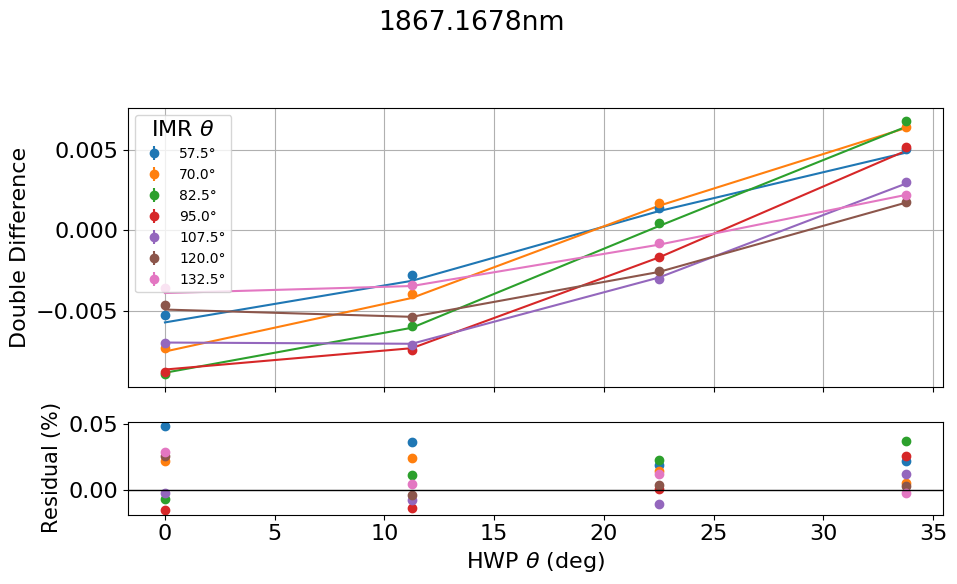

Updated Mueller Matrix:
[[ 0.50139344  0.1581948  -0.15916611 -0.44495823]
 [-0.49834431 -0.1591125   0.16014552  0.44769608]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.015486998542430297 0.048282306818485554
s_res: 0.02007800152625752
Error: [6.84495186e-05]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.5253e-04                                    7.91e-02    
       1              2         6.6072e-07      3.52e-04       8.81e-03       6.91e-04    
       2              3         6.3338e-07      2.73e-08       7.84e-05       5.47e-08    
       3              4         6.3338e-07      1.71e-16       6.20e-09       4.77e-12    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 3.5253e-04, final cost 6.3338e-07, first-order optimality 4.77e-12.
     message: `gtol` termination condition is sati

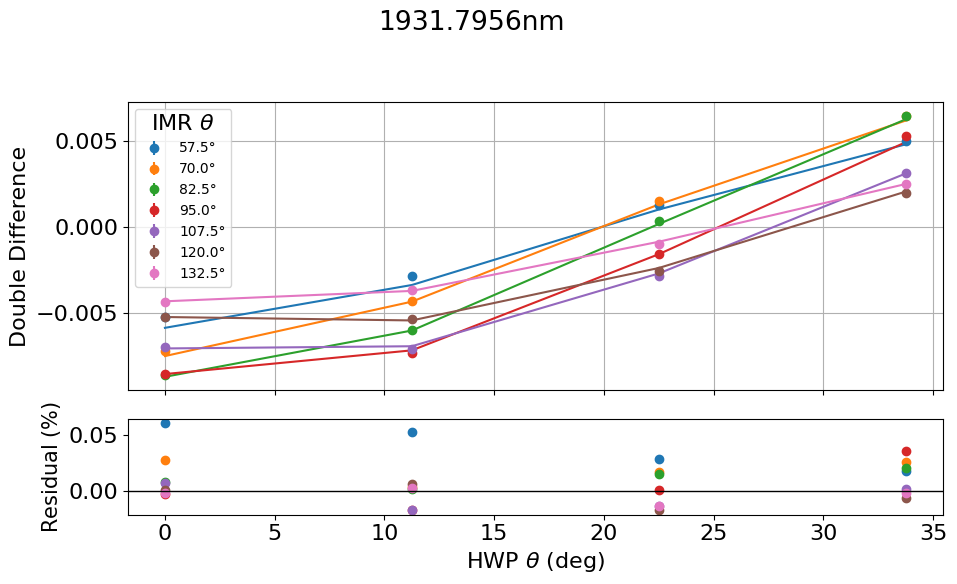

Updated Mueller Matrix:
[[ 0.50147553  0.17054191 -0.18284212 -0.43058995]
 [-0.49791891 -0.17170371  0.18415602  0.43368404]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.01670503134198048 0.060481513634752515
s_res: 0.021660329181009772
Error: [7.26040472e-05]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.4669e-04                                    7.95e-02    
       1              2         6.1231e-07      3.46e-04       8.63e-03       6.80e-04    
       2              3         5.8651e-07      2.58e-08       7.52e-05       5.16e-08    
       3              4         5.8651e-07      1.49e-16       5.71e-09       8.81e-12    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 3.4669e-04, final cost 5.8651e-07, first-order optimality 8.81e-12.
     message: `gtol` termination condition is sati

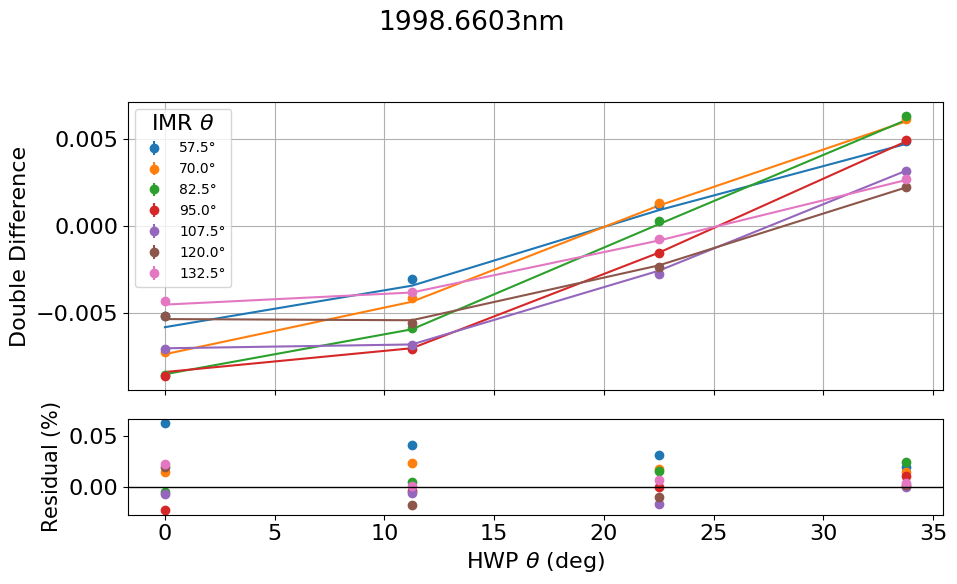

Updated Mueller Matrix:
[[ 0.50147971  0.17442443 -0.20112986 -0.42203506]
 [-0.49898951 -0.17525648  0.20213964  0.42415382]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.022928606808830132 0.06310536185135163
s_res: 0.020843450588352328
Error: [6.90013683e-05]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.3314e-04                                    7.82e-02    
       1              2         7.9832e-07      3.32e-04       8.43e-03       6.54e-04    
       2              3         7.7468e-07      2.36e-08       7.17e-05       4.73e-08    
       3              4         7.7468e-07      1.24e-16       5.19e-09       8.11e-13    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 3.3314e-04, final cost 7.7468e-07, first-order optimality 8.11e-13.
     message: `gtol` termination condition is sati

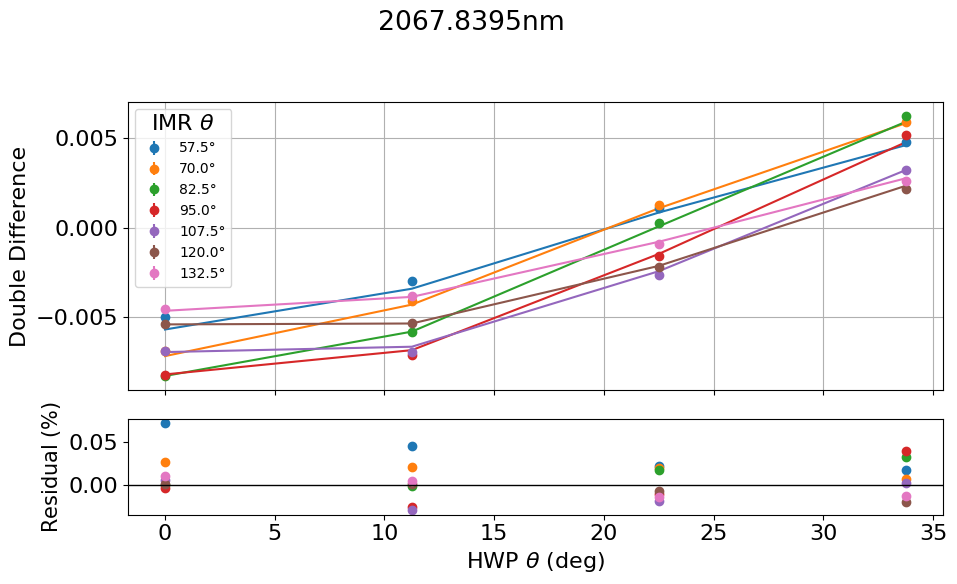

Updated Mueller Matrix:
[[ 0.50145242  0.17523172 -0.21708024 -0.4108211 ]
 [-0.49659204 -0.17687362  0.21921755  0.41486577]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.029589457530391217 0.07207094917705004
s_res: 0.023954946167714895
Error: [7.90158453e-05]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.1799e-04                                    7.66e-02    
       1              2         6.1037e-07      3.17e-04       8.22e-03       6.24e-04    
       2              3         5.8894e-07      2.14e-08       6.81e-05       4.28e-08    
       3              4         5.8894e-07      1.01e-16       4.67e-09       1.25e-13    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 3.1799e-04, final cost 5.8894e-07, first-order optimality 1.25e-13.
     message: `gtol` termination condition is sati

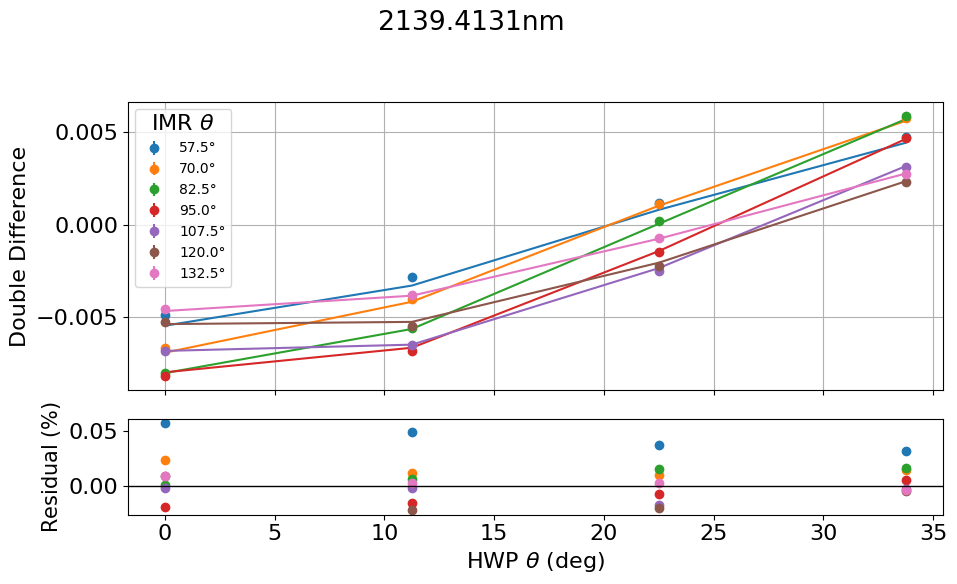

Updated Mueller Matrix:
[[ 0.50138907  0.1720342  -0.23094852 -0.40449618]
 [-0.49653786 -0.1736435   0.23321773  0.40847048]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.02210991606884316 0.05729448436862605
s_res: 0.020886676673580632
Error: [6.86712452e-05]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.0442e-04                                    7.45e-02    
       1              2         8.0390e-07      3.04e-04       8.09e-03       5.97e-04    
       2              3         7.8403e-07      1.99e-08       6.60e-05       3.97e-08    
       3              4         7.8403e-07      8.79e-17       4.39e-09       1.27e-13    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 3.0442e-04, final cost 7.8403e-07, first-order optimality 1.27e-13.
     message: `gtol` termination condition is satis

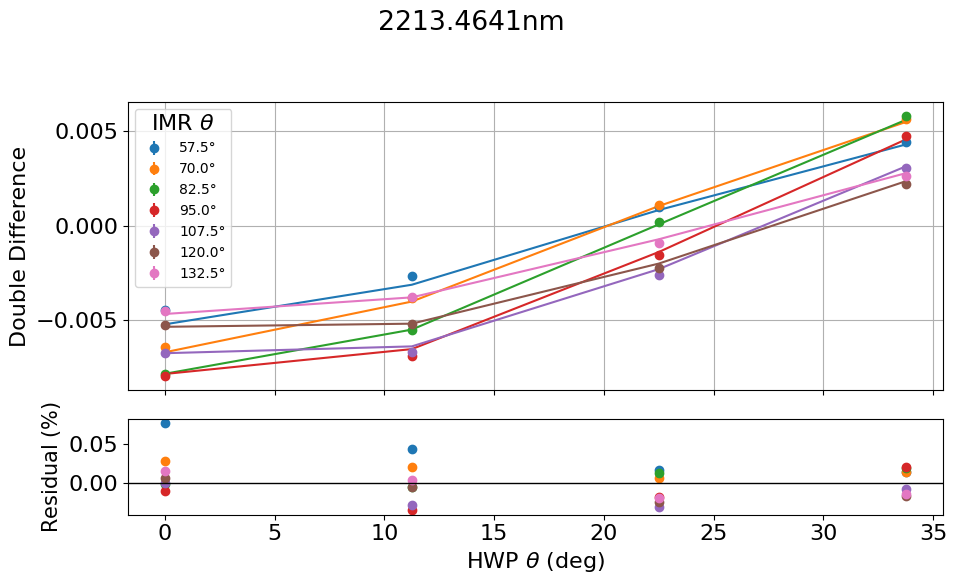

Updated Mueller Matrix:
[[ 0.50130782  0.1646728  -0.2416296  -0.39771675]
 [-0.4936397  -0.16711816  0.2454033   0.40392799]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.03414003146665989 0.07600732426843432
s_res: 0.024099032003292067
Error: [7.97465622e-05]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.8432e-04                                    7.14e-02    
       1              2         6.2269e-07      2.84e-04       7.89e-03       5.59e-04    
       2              3         6.0505e-07      1.76e-08       6.27e-05       3.53e-08    
       3              4         6.0505e-07      7.04e-17       3.96e-09       1.80e-12    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 2.8432e-04, final cost 6.0505e-07, first-order optimality 1.80e-12.
     message: `gtol` termination condition is satis

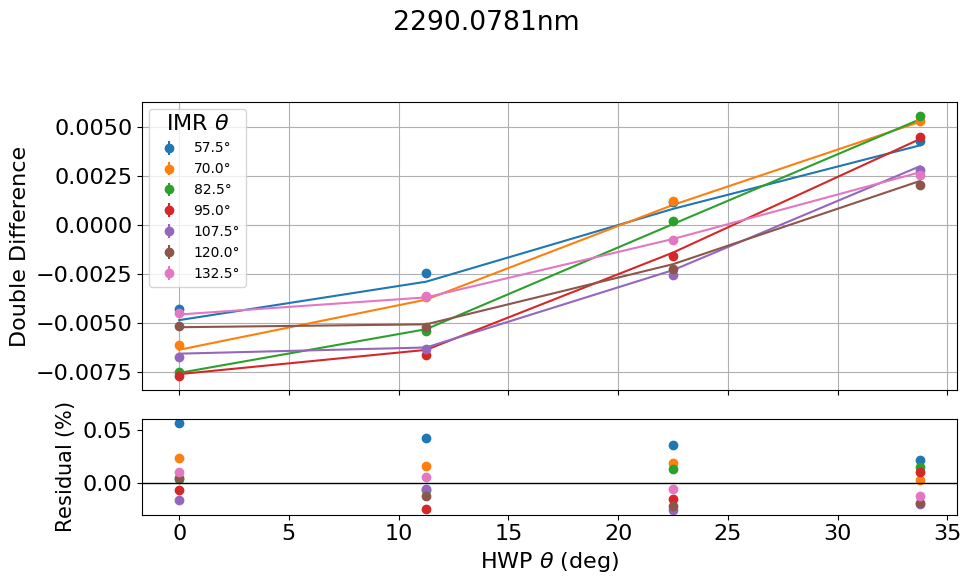

Updated Mueller Matrix:
[[ 0.5011729   0.15176333 -0.25374107 -0.39286734]
 [-0.49169182 -0.15455134  0.25865767  0.4004795 ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.02611241911543427 0.05674528642073545
s_res: 0.02117033386699358
Error: [7.06408255e-05]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.5971e-04                                    6.67e-02    
       1              2         1.1055e-06      2.59e-04       7.70e-03       5.09e-04    
       2              3         1.0901e-06      1.53e-08       5.97e-05       3.06e-08    
       3              4         1.0901e-06      5.54e-17       3.59e-09       5.05e-12    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 2.5971e-04, final cost 1.0901e-06, first-order optimality 5.05e-12.
     message: `gtol` termination condition is satisf

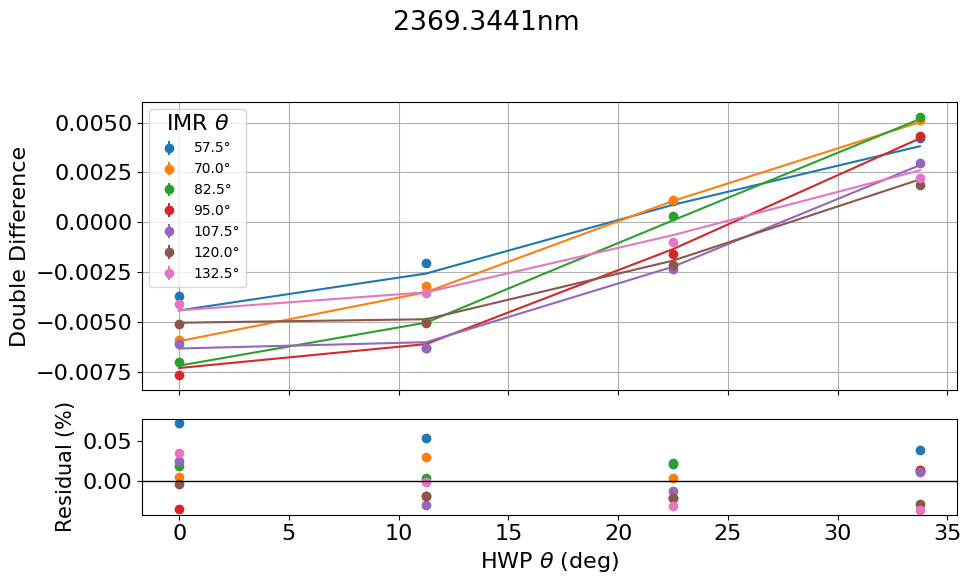

Updated Mueller Matrix:
[[ 0.50104215  0.13849727 -0.26114522 -0.38371776]
 [-0.48437251 -0.14302102  0.27017226  0.39698144]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
112 56
Residuals range: -0.03762086305635495 0.07234840470818965
s_res: 0.0284167086235127
Error: [9.68957059e-05]


In [3]:
# Fit all 22 wavelength bins
from pyPolCal.instruments import fit_CHARIS_Mueller_matrix_by_bin_nbs_unpol
from pathlib import Path
errors = []
sres_list = []
for bin in range(0,22):
    error,fig,ax,sres = fit_CHARIS_Mueller_matrix_by_bin_nbs_unpol(
        f'../datacsvs/nbs_in_internalcal_unpol/bin{bin}.csv',bin,
        Path(f'../fitted_p_dicts/nbs_in_unpol_internalcal/bin{bin}.json'),
    )
    errors.append(error)
    sres_list.append(sres)



In [4]:
# find average error
import numpy as np
errors = np.array(errors)
print('eps', np.mean(errors[:,0]))



eps 9.998736745109303e-05


Text(0, 0.5, 's_unpol (\\%)')

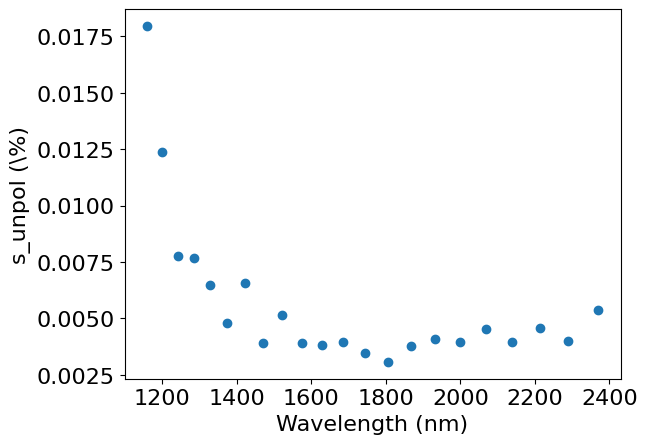

In [5]:
# calculate and plot pol accuracy
import matplotlib.pyplot as plt
from pyPolCal.constants import wavelength_bins

# number of double diff data points will be half the data points in the csv
interleaved_values, interleaved_stds, config_list = read_csv('../datacsvs/nbs_in_internalcal_unpol/bin0.csv')
N = len(interleaved_values) / 4
s_unpol = sres_list/np.sqrt(N)
plt.scatter(wavelength_bins,s_unpol)
plt.xlabel('Wavelength (nm)')
plt.ylabel('s_unpol (\%)')

In [6]:
# save s_unpol for use in tutorial notebook
with open('/home/thomasmc/pyPolCal/pyPolCal/tutorial_notebooks/CHARIS_fitting_tutorial/s_unpol.txt','w') as f:
    for sr in s_unpol:
        f.write(f"{sr}\n")

`model_data` will list out all of your fits in a data frame.

In [7]:
from pyPolCal.csv_tools import model_data
json_dir = '../fitted_p_dicts/nbs_in_unpol_internalcal'
df = model_data(json_dir, offsets=False)
df

,wavelength_bin,lp_epsilon
0,1159.5614,0.012207
1,1199.6971,0.011352
2,1241.2219,0.011572
3,1284.1840,0.011192
4,1328.6331,0.011158
5,1374.6208,0.010919
6,1422.2002,0.010693
7,1471.4264,0.010441
8,1522.3565,0.010389
9,1575.0495,0.010281


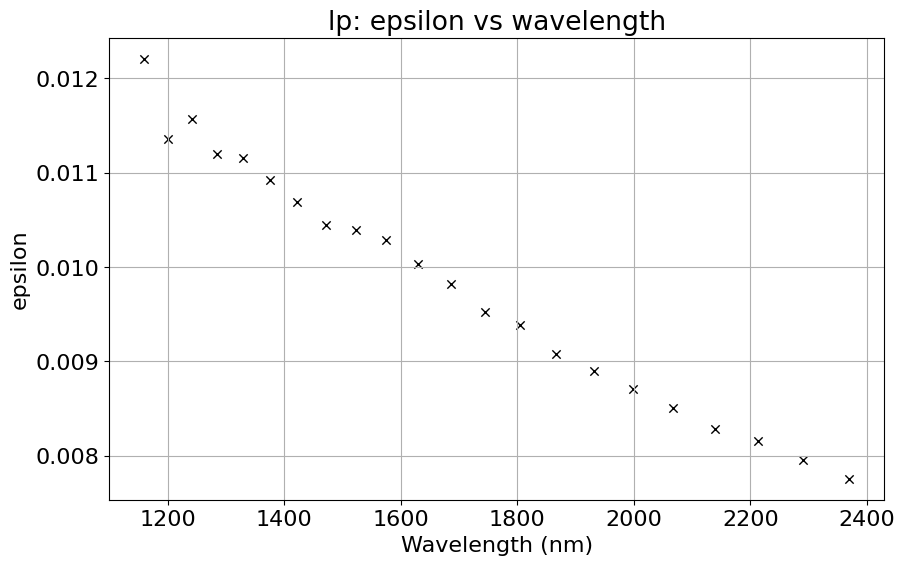

In [8]:
from pyPolCal.plotting import plot_config_dict_vs_wavelength
params, fig, ax = plot_config_dict_vs_wavelength('lp', 'epsilon', json_dir)
#fig, ax = plt.subplots(figsize=(10,6))
#ax.scatter(wavelength_bins, np.rad2deg(params))
#ax.plot(wavelength_bins,np.rad2deg((IMR_retardance(wavelength_bins,264.14673))), label='IMR Retardance Model', color='black', linestyle='--')